# Week 8 Capstone — End-to-End ML Pipeline

This is your Phase 1 capstone. You will build a complete ML pipeline from raw data to final evaluation — no worked examples, just you and the problem.

**Dataset:** Titanic (binary classification — predict who survived)

**Goal:** Beat the Kaggle baseline score of ~0.77 accuracy

**What this tests:**
- EDA and data cleaning (week 2)
- Model evaluation with cross-validation (week 3)
- Feature engineering: encoding, transforms, interactions (week 7)
- Algorithm comparison (weeks 5-6)
- Hyperparameter tuning (week 6)

Work through each section in order. Each section has clear deliverables.

---

## Setup

Download the Titanic dataset from Kaggle:
1. Go to https://www.kaggle.com/c/titanic/data
2. Download `train.csv` and `test.csv`
3. Put them in this folder: `week-08-capstone/data/`

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, f_classif

try:
    from xgboost import XGBClassifier
    XGBOOST = True
except ImportError:
    XGBOOST = False
    print('XGBoost not available - will use GradientBoostingClassifier instead')

# Load data
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
print()
print(train.head())

Train shape: (891, 12)
Test shape:  (418, 11)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0

---
## Part 1 — EDA

**Deliverables:**
1. Print `.info()` and `.describe()` — what are the data types and ranges?
2. Print missing value counts for each column
3. Plot survival rate by: Sex, Pclass, Embarked
4. Plot age distribution (raw)
5. Written answer: which features look most predictive of survival?

In [123]:
# Part 1 - EDA
# YOUR CODE HERE
print("Data Info")
print("==========================================================")
train.info()
print()

print("Data Describe")
print("==========================================================")
print(train.describe())
print()

print("Missing Count per Column")
print("==========================================================")
missing = train.isnull().sum()
missing_pct = ((missing / len(train)) * 100).round(2)
missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_%': missing_pct
})
print(missing_summary[missing_summary['missing_count'] > 0])

Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Data Describe
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     2

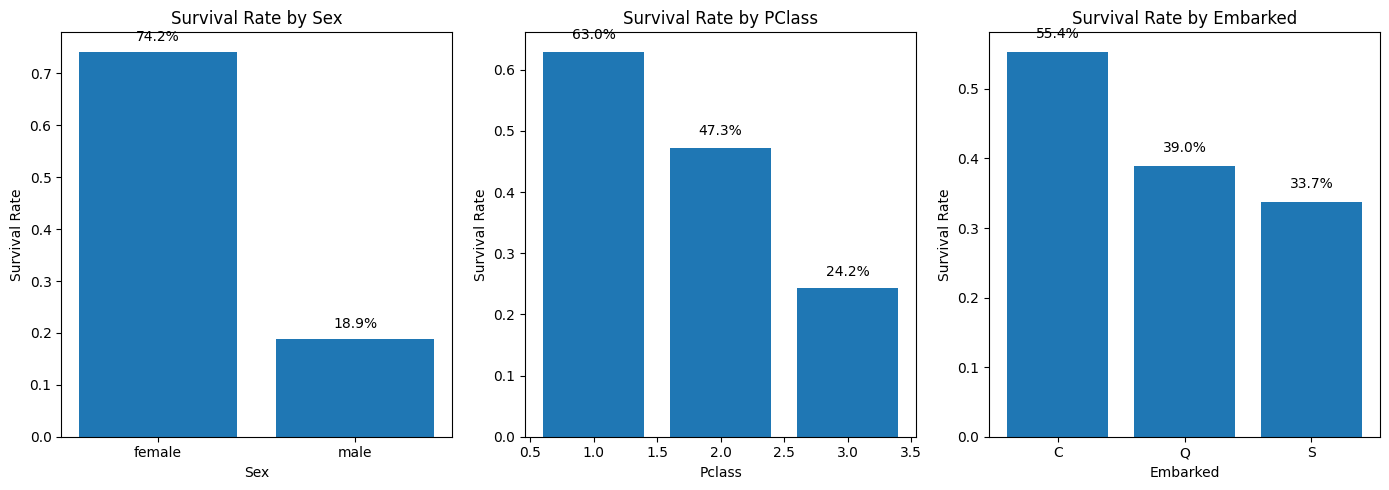

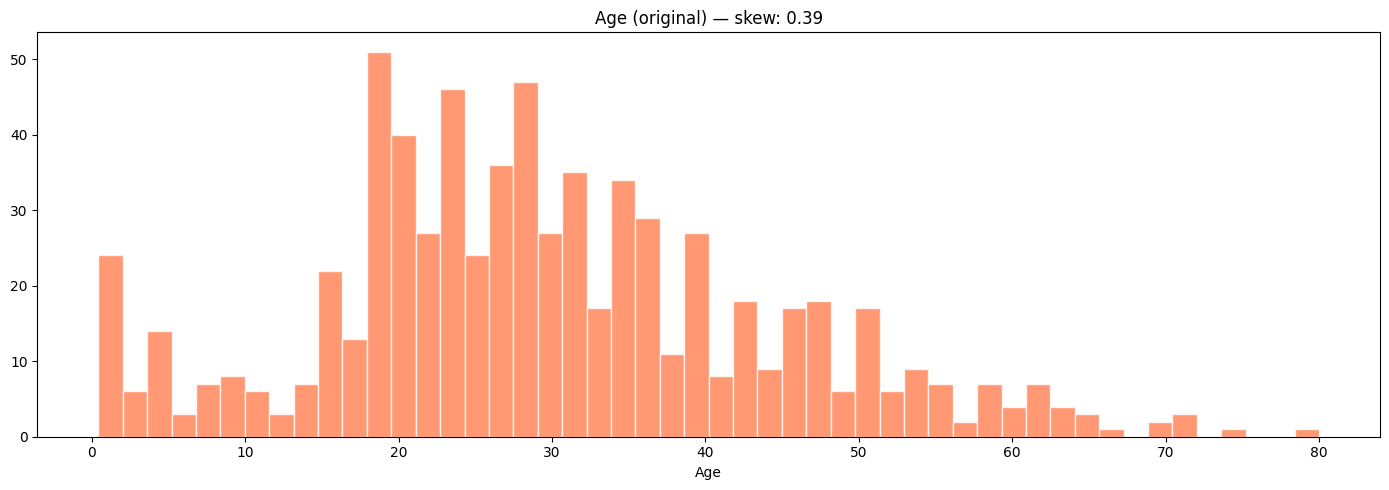

In [124]:
survival_by_sex = train.groupby('Sex')['Survived'].mean()
survival_by_pclass = train.groupby('Pclass')['Survived'].mean()
survival_by_embarked = train.groupby('Embarked')['Survived'].mean()

survival_by = [
    (0, "Survival Rate by Sex", "Sex", survival_by_sex),
    (1, "Survival Rate by PClass", "Pclass", survival_by_pclass),
    (2, "Survival Rate by Embarked", "Embarked", survival_by_embarked),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for index, title, x_label, df in survival_by:
    axes[index].bar(df.index, df.values)
    axes[index].set_xlabel(x_label)
    axes[index].set_ylabel('Survival Rate')
    axes[index].set_title(title)

    if index == 1:
        for i, v in enumerate(df.values):
            axes[index].text(i + 1, v + 0.02, f'{v:.1%}', ha='center')
    else:
        for i, v in enumerate(df.values):
            axes[index].text(i, v + 0.02, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(14, 5))
axes.hist(train['Age'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes.set_title(f'Age (original) — skew: {train["Age"].skew():.2f}')
axes.set_xlabel('Age')

plt.tight_layout()
plt.show()

# Based on data alone, Sex, Class, and Embarked (surprisingly) has clear distinction of survival rate.
# Also Age shows relatively normal distribution (slightly right skewed).
# So 4 features are probably useful
# 
# Name, Passenger ID, Ticket just by common sense wouldn't impact survival rate unless name gives you power

---
## Part 2 — Data Cleaning

**Deliverables:**
1. Fill missing `Age` values with the median age
2. Fill missing `Embarked` with the most common value
3. Drop the `Cabin` column (too many missing values)
4. Drop columns that won't be useful: `PassengerId`, `Name`, `Ticket`
5. Print the shape after cleaning and confirm no missing values remain

In [125]:
# Part 2 - Data Cleaning
# YOUR CODE HERE
train_clean = train.copy()

median_age = train['Age'].median()
train_clean['Age'] = train_clean['Age'].fillna(median_age)

mode_embark = train_clean['Embarked'].mode()[0]
train_clean['Embarked'] = train_clean['Embarked'].fillna(mode_embark)

dropping_columns = ['PassengerId', 'Name', 'Cabin', 'Ticket']
train_clean = train_clean.drop(columns=dropping_columns)

print(train_clean.shape)
print('\nMissing values after cleaning:')
print(train_clean.isnull().sum()[train_clean.isnull().sum() > 0])

(891, 8)

Missing values after cleaning:
Series([], dtype: int64)


---
## Part 3 — Feature Engineering

**Deliverables:**
1. One-hot encode `Sex` and `Embarked`
2. Create at least 2 new features (examples below — use your judgment):
   - `family_size` = SibSp + Parch + 1
   - `is_alone` = 1 if family_size == 1, else 0
   - `age_class` = Age * Pclass (interaction)
3. Print the final feature list
4. Split into X (features) and y (Survived)
5. Train/test split: 80/20, stratify on y, random_state=42

In [126]:
# Part 3 - Feature Engineering
# YOUR CODE HERE
train_encode = train_clean.copy()
train_encode = pd.get_dummies(train_encode, columns=['Sex'], prefix='Sex')
train_encode = pd.get_dummies(train_encode, columns=['Embarked'], prefix='Embarked')
#  Will not create any new feature as current data is already good

print("Final Feature List")
print(train_encode.columns.tolist())

X = train_encode.drop(columns=['Survived'])
y = train_encode['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,  stratify=y)

Final Feature List
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


---
## Part 4 — Model Comparison

**Deliverables:**
1. Compare at least 4 models using 5-fold CV accuracy on the training set:
   - Logistic Regression
   - Random Forest
   - Gradient Boosting / XGBoost
   - kNN
2. Print mean +- std for each
3. Plot a boxplot comparing all models
4. Written answer: which model won and why do you think that is?

In [127]:
# Part 4 - Model Comparison
# YOUR CODE HERE
models = [
    ('LogisticRegression', LogisticRegression()),
    ('Random Forest', RandomForestClassifier()),
    ('XGBoost', XGBClassifier()),
    ('KNN', Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]))
]

for label, model in models:
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    mean = score.mean()
    std = score.std()

    print(f'{label}: accuracy: {mean} std: {std}')

# Based on the result KNN performs the best after implementing stand scaler to close gap between datas
# This is unexpected consider we are working with 8 dimension, but looking at the data range of individual features are mostly
# small exception of age and ticket price (mostly categorical).

LogisticRegression: accuracy: 0.796405003447257 std: 0.021619582570471873
Random Forest: accuracy: 0.7922879936964443 std: 0.054167531193365884
XGBoost: accuracy: 0.8006599034768049 std: 0.03562049277008137
KNN: accuracy: 0.8104501132670148 std: 0.02301940973660328


---
## Part 5 — Hyperparameter Tuning

**Deliverables:**
1. Take your best model from Part 4
2. Use GridSearchCV or RandomizedSearchCV to tune at least 2 parameters
3. Print best params and best CV score
4. Did tuning improve over the default?

In [128]:
# Part 5 - Hyperparameter Tuning
# YOUR CODE HERE

pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

param_grid = {
    'knn__n_neighbors': [5, 10, 20],
    'knn__weights': ['uniform', 'distance'],
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print(f'Best CV accuracy: {grid.best_score_:.4f}')
print()

Best params: {'knn__n_neighbors': 10, 'knn__weights': 'uniform'}
Best CV accuracy: 0.8147



---
## Part 6 — Final Evaluation

**Deliverables:**
1. Train the best tuned model on the full training set
2. Evaluate on the test set (this is the one time you touch the test set)
3. Print classification report
4. Plot confusion matrix
5. If using tree model: plot top 10 feature importances

              precision    recall  f1-score   support

           0       0.83      0.92      0.87       110
           1       0.84      0.71      0.77        69

    accuracy                           0.84       179
   macro avg       0.84      0.81      0.82       179
weighted avg       0.84      0.84      0.83       179



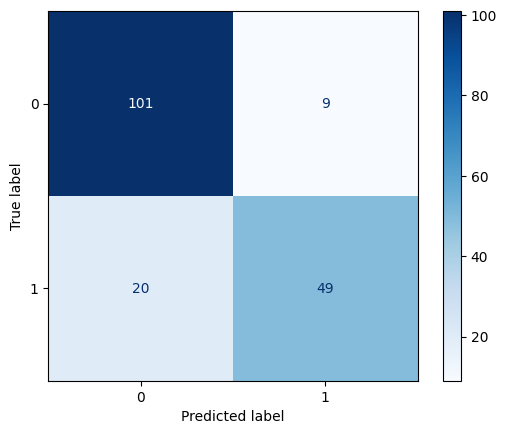

In [129]:
# Part 6 - Final Evaluation
# YOUR CODE HERE
def preprocess(df, median_age, train_columns=None):
    df = df.copy()
    
    # clean
    df['Age'] = df['Age'].fillna(median_age)
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())  # test.csv has 1 missing
    df = df.drop(columns=['PassengerId', 'Name', 'Cabin', 'Ticket'], errors='ignore')
    
    # encode
    df = pd.get_dummies(df, columns=['Sex', 'Embarked'], prefix=['Sex', 'Embarked'])

    
    # drop target if present
    df = df.drop(columns=['Survived'], errors='ignore')
    
    # align columns to training set
    if train_columns is not None:
        df = df.reindex(columns=train_columns, fill_value=0)
    
    return df

# Part 6
median_age = train['Age'].median()

best_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=10, weights='uniform'))])
best_pipe.fit(X, y)

y_pred = best_pipe.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()


---
## Part 7 — Kaggle Submission

**Deliverables:**
1. Apply the same cleaning and feature engineering to `test.csv`
2. Generate predictions
3. Save as `submission.csv` in the format Kaggle expects
4. Submit to Kaggle and paste your score as a comment

In [130]:
# Part 7 - Kaggle Submission
# YOUR CODE HERE

# Apply same preprocessing to test.csv
# ...

# Generate predictions
# predictions = best_model.predict(X_test_kaggle)

# Save submission
# submission = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': predictions})
# submission.to_csv('data/submission.csv', index=False)
# print('Saved submission.csv')
# print(submission.head())

# Kaggle score:  0.78229
X_test_kaggle = preprocess(test, median_age, None)
predictions = best_pipe.predict(X_test_kaggle)

submission = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': predictions})
submission.to_csv('data/submission.csv', index=False)
print('Saved submission.csv')
print(submission.head())


Saved submission.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
